In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from scipy.stats import f_oneway, ttest_ind, chi2_contingency
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

# Capstone - Hospitalization Analisys

In [2]:
#read file
hospital = pd.read_csv('Hospitalisation details.csv')
hospital

,Customer ID,year,month,date,children,charges,Hospital tier,City tier,State ID
0,Id2335,1992,Jul,9,0,563.84,tier - 2,tier - 3,R1013
1,Id2334,1992,Nov,30,0,570.62,tier - 2,tier - 1,R1013
2,Id2333,1993,Jun,30,0,600.00,tier - 2,tier - 1,R1013
3,Id2332,1992,Sep,13,0,604.54,tier - 3,tier - 3,R1013
4,Id2331,1998,Jul,27,0,637.26,tier - 3,tier - 3,R1013
...,...,...,...,...,...,...,...,...,...
2338,Id5,1989,Jun,19,0,55135.40,tier - 1,tier - 2,R1012
2339,Id4,1991,Jun,6,1,58571.07,tier - 1,tier - 3,R1024
2340,Id3,1970,?,11,3,60021.40,tier - 1,tier - 1,R1012
2341,Id2,1977,Jun,8,0,62592.87,tier - 2,tier - 3,R1013


In [3]:
#read file
examination = pd.read_csv('Medical Examinations.csv')
examination

,Customer ID,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker
0,Id1,47.410,7.47,No,No,No,No major surgery,yes
1,Id2,30.360,5.77,No,No,No,No major surgery,yes
2,Id3,34.485,11.87,yes,No,No,2,yes
3,Id4,38.095,6.05,No,No,No,No major surgery,yes
4,Id5,35.530,5.45,No,No,No,No major surgery,yes
...,...,...,...,...,...,...,...,...
2330,Id2331,22.340,5.57,No,No,No,1,No
2331,Id2332,17.700,6.28,No,No,No,1,No
2332,Id2333,16.470,6.35,No,No,Yes,1,No
2333,Id2334,17.600,4.39,No,No,No,1,No


In [4]:
#read file
names = pd.read_excel("Names.xlsx")
names

,Customer ID,name
0,Id1,"Hawks, Ms. Kelly"
1,Id2,"Lehner, Mr. Matthew D"
2,Id3,"Lu, Mr. Phil"
3,Id4,"Osborne, Ms. Kelsey"
4,Id5,"Kadala, Ms. Kristyn"
...,...,...
2330,Id2331,"Brietzke, Mr. Jordan"
2331,Id2332,"Riveros Gonzalez, Mr. Juan D. Sr."
2332,Id2333,"Albano, Ms. Julie"
2333,Id2334,"Rosendahl, Mr. Evan P"


## Data Science

### Data Preparation

In [5]:
#Merge datasets
data = hospital.merge(names, on = 'Customer ID')
data = data.merge(examination, on = 'Customer ID')
data

,Customer ID,year,month,date,children,charges,Hospital tier,City tier,State ID,name,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker
0,Id2335,1992,Jul,9,0,563.84,tier - 2,tier - 3,R1013,"German, Mr. Aaron K",17.580,4.51,No,No,No,1,No
1,Id2334,1992,Nov,30,0,570.62,tier - 2,tier - 1,R1013,"Rosendahl, Mr. Evan P",17.600,4.39,No,No,No,1,No
2,Id2333,1993,Jun,30,0,600.00,tier - 2,tier - 1,R1013,"Albano, Ms. Julie",16.470,6.35,No,No,Yes,1,No
3,Id2332,1992,Sep,13,0,604.54,tier - 3,tier - 3,R1013,"Riveros Gonzalez, Mr. Juan D. Sr.",17.700,6.28,No,No,No,1,No
4,Id2331,1998,Jul,27,0,637.26,tier - 3,tier - 3,R1013,"Brietzke, Mr. Jordan",22.340,5.57,No,No,No,1,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2330,Id5,1989,Jun,19,0,55135.40,tier - 1,tier - 2,R1012,"Kadala, Ms. Kristyn",35.530,5.45,No,No,No,No major surgery,yes
2331,Id4,1991,Jun,6,1,58571.07,tier - 1,tier - 3,R1024,"Osborne, Ms. Kelsey",38.095,6.05,No,No,No,No major surgery,yes
2332,Id3,1970,?,11,3,60021.40,tier - 1,tier - 1,R1012,"Lu, Mr. Phil",34.485,11.87,yes,No,No,2,yes
2333,Id2,1977,Jun,8,0,62592.87,tier - 2,tier - 3,R1013,"Lehner, Mr. Matthew D",30.360,5.77,No,No,No,No major surgery,yes


In [6]:
#Check for null values
data.isna().sum()

Customer ID               0
year                      0
month                     0
date                      0
children                  0
charges                   0
Hospital tier             0
City tier                 0
State ID                  0
name                      0
BMI                       0
HBA1C                     0
Heart Issues              0
Any Transplants           0
Cancer history            0
NumberOfMajorSurgeries    0
smoker                    0
dtype: int64

In [7]:
#Convert ? to null 
data = data.replace('?', np.nan)

In [8]:
#check nulls again
data.isna().sum()

Customer ID               0
year                      2
month                     3
date                      0
children                  0
charges                   0
Hospital tier             1
City tier                 1
State ID                  2
name                      0
BMI                       0
HBA1C                     0
Heart Issues              0
Any Transplants           0
Cancer history            0
NumberOfMajorSurgeries    0
smoker                    2
dtype: int64

In [9]:
#Calculate percentqge of rows
null_rows = data.isna().any(axis=1).sum()
percent = (null_rows/len(data)*100)
print(f'The data contains {percent:.1f}% of rows with value "?".')

The data contains 0.4% of rows with value "?".


Since the percentage of this value is very low we can drop these rows from the dataset.

In [10]:
#drop rows
data = data.dropna()
data.isna().sum()

Customer ID               0
year                      0
month                     0
date                      0
children                  0
charges                   0
Hospital tier             0
City tier                 0
State ID                  0
name                      0
BMI                       0
HBA1C                     0
Heart Issues              0
Any Transplants           0
Cancer history            0
NumberOfMajorSurgeries    0
smoker                    0
dtype: int64

In [11]:
#Check datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2325 entries, 0 to 2334
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             2325 non-null   object 
 1   year                    2325 non-null   object 
 2   month                   2325 non-null   object 
 3   date                    2325 non-null   int64  
 4   children                2325 non-null   int64  
 5   charges                 2325 non-null   float64
 6   Hospital tier           2325 non-null   object 
 7   City tier               2325 non-null   object 
 8   State ID                2325 non-null   object 
 9   name                    2325 non-null   object 
 10  BMI                     2325 non-null   float64
 11  HBA1C                   2325 non-null   float64
 12  Heart Issues            2325 non-null   object 
 13  Any Transplants         2325 non-null   object 
 14  Cancer history          2325 non-null   

In [12]:
#Check unique values for nominal cols
print(data['Hospital tier'].unique())
print(data['City tier'].unique())
print(data['State ID'].unique())
print(data['Any Transplants'].unique())
print(data['Heart Issues'].unique())
print(data['Cancer history'].unique())
print(data['NumberOfMajorSurgeries'].unique())
print(data['smoker'].unique())

['tier - 2' 'tier - 3' 'tier - 1']
['tier - 3' 'tier - 1' 'tier - 2']
['R1013' 'R1012' 'R1011' 'R1015' 'R1019' 'R1016' 'R1018' 'R1025' 'R1024'
 'R1023' 'R1014' 'R1021' 'R1017' 'R1020' 'R1026' 'R1022']
['No' 'yes']
['No' 'yes']
['No' 'Yes']
['1' 'No major surgery' '2' '3']
['No' 'yes']


In [13]:
#5. Encode the target States and add rest of states as other
#chosen stateids
important_states = ['R1011','R1012','R1013']

#separates important and other groups
data['State_grouped'] = data['State ID'].where(data['State ID'].isin(important_states), 'Other')

#create dummies
state_dummies = pd.get_dummies(data['State_grouped'], prefix= 'State', drop_first= True)

#add to dataset
data = pd.concat([data, state_dummies], axis=1)
#drop old cols
data = data.drop(columns=['State ID', 'State_grouped'])
data

,Customer ID,year,month,date,children,charges,Hospital tier,City tier,name,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker,State_R1011,State_R1012,State_R1013
0,Id2335,1992,Jul,9,0,563.84,tier - 2,tier - 3,"German, Mr. Aaron K",17.580,4.51,No,No,No,1,No,0,0,1
1,Id2334,1992,Nov,30,0,570.62,tier - 2,tier - 1,"Rosendahl, Mr. Evan P",17.600,4.39,No,No,No,1,No,0,0,1
2,Id2333,1993,Jun,30,0,600.00,tier - 2,tier - 1,"Albano, Ms. Julie",16.470,6.35,No,No,Yes,1,No,0,0,1
3,Id2332,1992,Sep,13,0,604.54,tier - 3,tier - 3,"Riveros Gonzalez, Mr. Juan D. Sr.",17.700,6.28,No,No,No,1,No,0,0,1
4,Id2331,1998,Jul,27,0,637.26,tier - 3,tier - 3,"Brietzke, Mr. Jordan",22.340,5.57,No,No,No,1,No,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329,Id6,1962,Aug,4,0,52590.83,tier - 1,tier - 3,"Baker, Mr. Russell B.",32.800,6.59,No,No,No,No major surgery,yes,1,0,0
2330,Id5,1989,Jun,19,0,55135.40,tier - 1,tier - 2,"Kadala, Ms. Kristyn",35.530,5.45,No,No,No,No major surgery,yes,0,1,0
2331,Id4,1991,Jun,6,1,58571.07,tier - 1,tier - 3,"Osborne, Ms. Kelsey",38.095,6.05,No,No,No,No major surgery,yes,0,0,0
2333,Id2,1977,Jun,8,0,62592.87,tier - 2,tier - 3,"Lehner, Mr. Matthew D",30.360,5.77,No,No,No,No major surgery,yes,0,0,1


In [14]:
#Replace no major surgery to 0 and convert to int
data['NumberOfMajorSurgeries'] = data['NumberOfMajorSurgeries'].replace('No major surgery', 0)

#convert to int
data['NumberOfMajorSurgeries'] = pd.to_numeric(data['NumberOfMajorSurgeries'],errors = 'coerce')
data

,Customer ID,year,month,date,children,charges,Hospital tier,City tier,name,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker,State_R1011,State_R1012,State_R1013
0,Id2335,1992,Jul,9,0,563.84,tier - 2,tier - 3,"German, Mr. Aaron K",17.580,4.51,No,No,No,1,No,0,0,1
1,Id2334,1992,Nov,30,0,570.62,tier - 2,tier - 1,"Rosendahl, Mr. Evan P",17.600,4.39,No,No,No,1,No,0,0,1
2,Id2333,1993,Jun,30,0,600.00,tier - 2,tier - 1,"Albano, Ms. Julie",16.470,6.35,No,No,Yes,1,No,0,0,1
3,Id2332,1992,Sep,13,0,604.54,tier - 3,tier - 3,"Riveros Gonzalez, Mr. Juan D. Sr.",17.700,6.28,No,No,No,1,No,0,0,1
4,Id2331,1998,Jul,27,0,637.26,tier - 3,tier - 3,"Brietzke, Mr. Jordan",22.340,5.57,No,No,No,1,No,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329,Id6,1962,Aug,4,0,52590.83,tier - 1,tier - 3,"Baker, Mr. Russell B.",32.800,6.59,No,No,No,0,yes,1,0,0
2330,Id5,1989,Jun,19,0,55135.40,tier - 1,tier - 2,"Kadala, Ms. Kristyn",35.530,5.45,No,No,No,0,yes,0,1,0
2331,Id4,1991,Jun,6,1,58571.07,tier - 1,tier - 3,"Osborne, Ms. Kelsey",38.095,6.05,No,No,No,0,yes,0,0,0
2333,Id2,1977,Jun,8,0,62592.87,tier - 2,tier - 3,"Lehner, Mr. Matthew D",30.360,5.77,No,No,No,0,yes,0,0,1


In [15]:
data['month'].unique()

array(['Jul', 'Nov', 'Jun', 'Sep', 'Dec', 'Aug', 'Oct'], dtype=object)

In [16]:
#7 Calculate age
# convert object dates to int
data['year'] = pd.to_numeric(data['year'], errors='coerce')

#convert months to numeric
month_map = {'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
data['month_num'] = data['month'].map(month_map)
data['month_num'] = pd.to_numeric(data['month_num'], errors='coerce')
#create data of birth
data['DOB'] = pd.to_datetime(dict(year = data['year'], month = data['month_num'], day = data['date']),errors='coerce')

#Calculate age
today = pd.Timestamp.today().normalize()
data['Age'] = (today - data['DOB']).dt.days // 365
data

,Customer ID,year,month,date,children,charges,Hospital tier,City tier,name,BMI,...,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker,State_R1011,State_R1012,State_R1013,month_num,DOB,Age
0,Id2335,1992,Jul,9,0,563.84,tier - 2,tier - 3,"German, Mr. Aaron K",17.580,...,No,No,1,No,0,0,1,7,1992-07-09,33
1,Id2334,1992,Nov,30,0,570.62,tier - 2,tier - 1,"Rosendahl, Mr. Evan P",17.600,...,No,No,1,No,0,0,1,11,1992-11-30,33
2,Id2333,1993,Jun,30,0,600.00,tier - 2,tier - 1,"Albano, Ms. Julie",16.470,...,No,Yes,1,No,0,0,1,6,1993-06-30,32
3,Id2332,1992,Sep,13,0,604.54,tier - 3,tier - 3,"Riveros Gonzalez, Mr. Juan D. Sr.",17.700,...,No,No,1,No,0,0,1,9,1992-09-13,33
4,Id2331,1998,Jul,27,0,637.26,tier - 3,tier - 3,"Brietzke, Mr. Jordan",22.340,...,No,No,1,No,0,0,1,7,1998-07-27,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329,Id6,1962,Aug,4,0,52590.83,tier - 1,tier - 3,"Baker, Mr. Russell B.",32.800,...,No,No,0,yes,1,0,0,8,1962-08-04,63
2330,Id5,1989,Jun,19,0,55135.40,tier - 1,tier - 2,"Kadala, Ms. Kristyn",35.530,...,No,No,0,yes,0,1,0,6,1989-06-19,36
2331,Id4,1991,Jun,6,1,58571.07,tier - 1,tier - 3,"Osborne, Ms. Kelsey",38.095,...,No,No,0,yes,0,0,0,6,1991-06-06,34
2333,Id2,1977,Jun,8,0,62592.87,tier - 2,tier - 3,"Lehner, Mr. Matthew D",30.360,...,No,No,0,yes,0,0,1,6,1977-06-08,48


In [17]:
#drop unnecessary columns
data.drop(columns=['month_num', 'date', 'year', 'month'], inplace = True)
data

,Customer ID,children,charges,Hospital tier,City tier,name,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker,State_R1011,State_R1012,State_R1013,DOB,Age
0,Id2335,0,563.84,tier - 2,tier - 3,"German, Mr. Aaron K",17.580,4.51,No,No,No,1,No,0,0,1,1992-07-09,33
1,Id2334,0,570.62,tier - 2,tier - 1,"Rosendahl, Mr. Evan P",17.600,4.39,No,No,No,1,No,0,0,1,1992-11-30,33
2,Id2333,0,600.00,tier - 2,tier - 1,"Albano, Ms. Julie",16.470,6.35,No,No,Yes,1,No,0,0,1,1993-06-30,32
3,Id2332,0,604.54,tier - 3,tier - 3,"Riveros Gonzalez, Mr. Juan D. Sr.",17.700,6.28,No,No,No,1,No,0,0,1,1992-09-13,33
4,Id2331,0,637.26,tier - 3,tier - 3,"Brietzke, Mr. Jordan",22.340,5.57,No,No,No,1,No,0,0,1,1998-07-27,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329,Id6,0,52590.83,tier - 1,tier - 3,"Baker, Mr. Russell B.",32.800,6.59,No,No,No,0,yes,1,0,0,1962-08-04,63
2330,Id5,0,55135.40,tier - 1,tier - 2,"Kadala, Ms. Kristyn",35.530,5.45,No,No,No,0,yes,0,1,0,1989-06-19,36
2331,Id4,1,58571.07,tier - 1,tier - 3,"Osborne, Ms. Kelsey",38.095,6.05,No,No,No,0,yes,0,0,0,1991-06-06,34
2333,Id2,0,62592.87,tier - 2,tier - 3,"Lehner, Mr. Matthew D",30.360,5.77,No,No,No,0,yes,0,0,1,1977-06-08,48


In [18]:
#8 get genders
def gender(name):
    if 'Ms' in name or 'Mrs' in name:
        return 'Female'
    else:
        return 'Male'

#create gender column
data['Gender'] = data['name'].map(gender)
data

,Customer ID,children,charges,Hospital tier,City tier,name,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker,State_R1011,State_R1012,State_R1013,DOB,Age,Gender
0,Id2335,0,563.84,tier - 2,tier - 3,"German, Mr. Aaron K",17.580,4.51,No,No,No,1,No,0,0,1,1992-07-09,33,Male
1,Id2334,0,570.62,tier - 2,tier - 1,"Rosendahl, Mr. Evan P",17.600,4.39,No,No,No,1,No,0,0,1,1992-11-30,33,Male
2,Id2333,0,600.00,tier - 2,tier - 1,"Albano, Ms. Julie",16.470,6.35,No,No,Yes,1,No,0,0,1,1993-06-30,32,Female
3,Id2332,0,604.54,tier - 3,tier - 3,"Riveros Gonzalez, Mr. Juan D. Sr.",17.700,6.28,No,No,No,1,No,0,0,1,1992-09-13,33,Male
4,Id2331,0,637.26,tier - 3,tier - 3,"Brietzke, Mr. Jordan",22.340,5.57,No,No,No,1,No,0,0,1,1998-07-27,27,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329,Id6,0,52590.83,tier - 1,tier - 3,"Baker, Mr. Russell B.",32.800,6.59,No,No,No,0,yes,1,0,0,1962-08-04,63,Male
2330,Id5,0,55135.40,tier - 1,tier - 2,"Kadala, Ms. Kristyn",35.530,5.45,No,No,No,0,yes,0,1,0,1989-06-19,36,Female
2331,Id4,1,58571.07,tier - 1,tier - 3,"Osborne, Ms. Kelsey",38.095,6.05,No,No,No,0,yes,0,0,0,1991-06-06,34,Female
2333,Id2,0,62592.87,tier - 2,tier - 3,"Lehner, Mr. Matthew D",30.360,5.77,No,No,No,0,yes,0,0,1,1977-06-08,48,Male


### Data Visualization

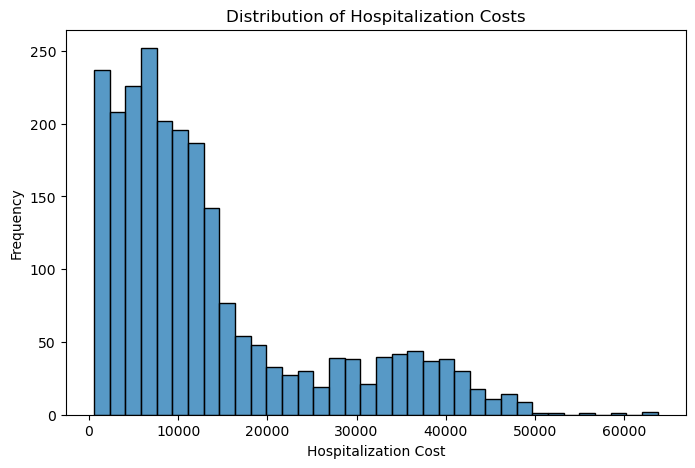

In [19]:
#plot costs hist
plt.figure(figsize=(8,5))
sns.histplot(data['charges'])
plt.xlabel('Hospitalization Cost')
plt.ylabel('Frequency')
plt.title('Distribution of Hospitalization Costs')
plt.show()

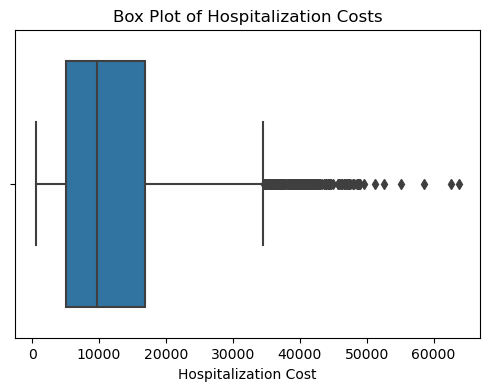

In [20]:
#plot box and whisker
plt.figure(figsize=(6,4))
sns.boxplot(x=data['charges'])
plt.xlabel('Hospitalization Cost')
plt.title('Box Plot of Hospitalization Costs')
plt.show()

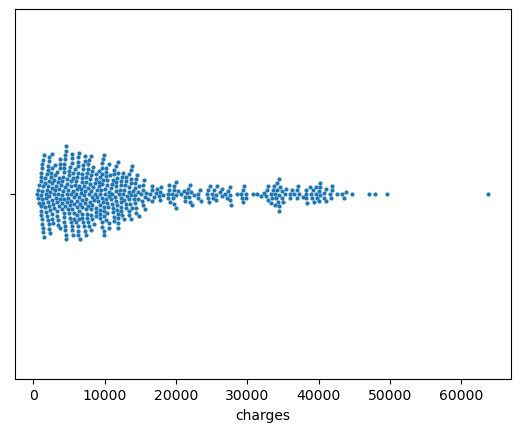

In [21]:
#Swarm plot
sns.swarmplot(x=data.sample(500)['charges'], size=3)
plt.show()

The Distribution of hospitalization cost is considerably rightly skewed, with significant number of outliers above the price of around 35k with most of the patients paying in the range of around 10k.

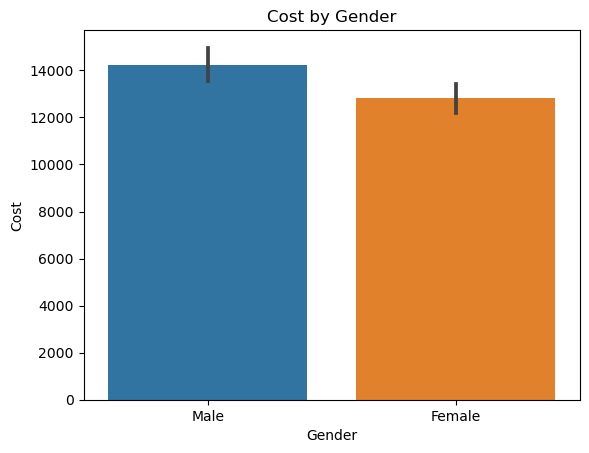

In [22]:
#10 charges for gender
sns.barplot(data = data, x = 'Gender', y = 'charges')
plt.title('Cost by Gender')
plt.xlabel('Gender')
plt.ylabel('Cost')
plt.show()

Male patients tend to pay higher hospitalization costs. 

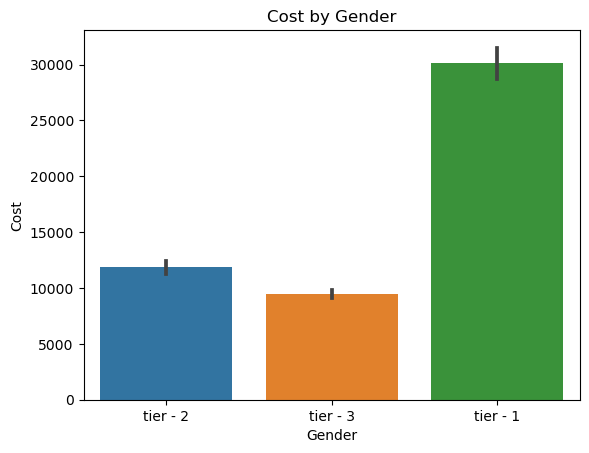

In [24]:
sns.barplot(data = data, x = 'Hospital tier', y = 'charges')
plt.title('Cost by Gender')
plt.xlabel('Gender')
plt.ylabel('Cost')
plt.show()

Tier 1 hospitals charge considerably more than tier 2 which comes in second which charge a bit more than tier 3 hospitals. This means that the better the hospital the higher they will charge hospitalized patients as they would offer better conditions and facilities which would cost more.

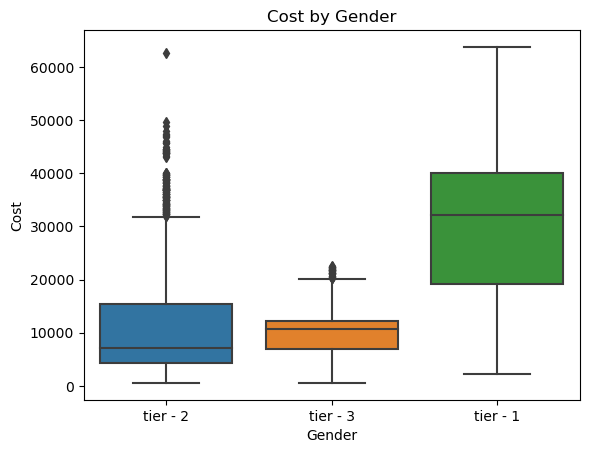

  Hospital tier  MedianCharges
0      tier - 1      32097.435
1      tier - 2       7168.760
2      tier - 3      10676.830


In [25]:
# 11 median hospitalization for hospital tier

#get the medians
median_charges = (data.groupby('Hospital tier')['charges'].median().reset_index().rename(columns={'charges': 'MedianCharges'}))

sns.boxplot(data = data, x = 'Hospital tier', y = 'charges')
plt.title('Cost by Gender')
plt.xlabel('Gender')
plt.ylabel('Cost')
plt.show()
print(median_charges)

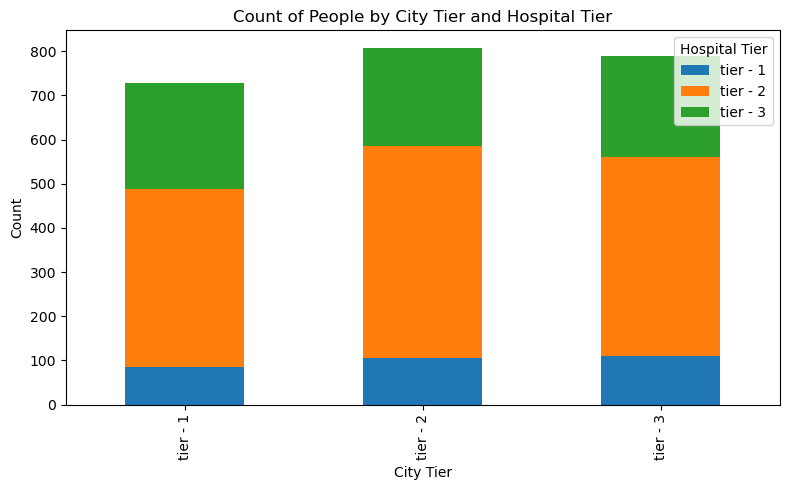

Hospital tier City tier  tier - 1  tier - 2  tier - 3
0              tier - 1        85       403       241
1              tier - 2       106       479       222
2              tier - 3       109       452       228


In [26]:
# Count of people in different city tiers and hospitals
# Frequency table
freq_table = pd.crosstab(data['City tier'], data['Hospital tier'])

# Stacked bar chart
freq_table.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Count of People by City Tier and Hospital Tier')
plt.xlabel('City Tier')
plt.ylabel('Count')
plt.legend(title='Hospital Tier')
plt.tight_layout()
plt.show()
print(freq_table.reset_index())

The majority of patients are hospitalized in tier 2 hospitals across all city tiers.

### Hypothesis Testing

13.a. 

H0 -The average hospitalization costs for the three types of hospitals are not significantly different.

H1 - The average hospitalization costs for the three types of hospitals are significantly different.

In [27]:
#create hypothesis result function
def result(p_value):
    if p_value >= 0.05:
        result =  'Null Hypothesis is Accepted'
    else:
        result =  'Null Hypothesis is rejected.\nAlternative Hypothesis is Accepted.'
    print(result)

In [28]:
#a)
tiers = data['Hospital tier'].unique()
charges_by_tier = [data[data['Hospital tier'] == t]['charges'] for t in tiers]

anova_hospital =  f_oneway(*charges_by_tier)
print(anova_hospital, '\n')
result(anova_hospital[1])

F_onewayResult(statistic=493.98956631117625, pvalue=1.7738221310852664e-179) 

Null Hypothesis is rejected.
Alternative Hypothesis is Accepted.


13.b.

The average hospitalization costs for the three types of cities are not significantly different.

The average hospitalization costs for the three types of cities are significantly different.

In [29]:
#b.
cities = data['City tier'].unique()
charges_by_city = [data[data['City tier'] == c]['charges'] for c in cities]

anova_city = f_oneway(*charges_by_city)
print(anova_city, '\n')
result(anova_city[1])

F_onewayResult(statistic=1.4543557561814664, pvalue=0.23376344386881315) 

Null Hypothesis is Accepted


13.c.
The average hospitalization cost for smokers is not significantly different from the average cost 
for nonsmokers.

The average hospitalization cost for smokers is significantly different from the average cost 
for nonsmokers.

In [30]:
#c.
smoker_charges = data[data['smoker'] == 'yes']['charges']
nonsmoker_charges = data[data['smoker'] == 'No']['charges']

ttest_smoker = ttest_ind(
    smoker_charges,
    nonsmoker_charges,
    equal_var=False
)
print(ttest_smoker, '\n')
result(ttest_smoker[1])

Ttest_indResult(statistic=56.316832285932286, pvalue=6.697431845033993e-238) 

Null Hypothesis is rejected.
Alternative Hypothesis is Accepted.


13.d. 

Smoking and heart issues are independent.


Smoking and heart issues are not independent.

In [31]:
#d.
contingency = pd.crosstab(data['smoker'], data['Heart Issues'])

chi2_test = chi2_contingency(contingency)
print(chi2_test, '\n')
result(chi2_test[1])

Chi2ContingencyResult(statistic=0.08588150449910657, pvalue=0.7694797581780767, dof=1, expected_freq=array([[1111.30967742,  727.69032258],
       [ 293.69032258,  192.30967742]])) 

Null Hypothesis is Accepted


## Machine Learning

In [32]:
#4. Encode categorical columns
hospital_map = {'tier - 1':2, 'tier - 2':1, 'tier - 3': 0}
city_map = {'tier - 1':2, 'tier - 2':1, 'tier - 3': 0}
binary_map = {'yes': 1, 'no': 0}
gender_map = {'Male':1, 'Female':0}

data['Hospital_tier_ord'] = data['Hospital tier'].str.lower().map(hospital_map)
data['City_tier_ord'] = data['City tier'].str.lower().map(city_map)
data['smoker_bin'] = data['smoker'].str.lower().map(binary_map)
data['HeartIssues_bin'] = data['Heart Issues'].str.lower().map(binary_map)
data['Transplants_bin'] = data['Any Transplants'].str.lower().map(binary_map)
data['CancerHistory_bin'] = data['Cancer history'].str.lower().map(binary_map)
data['Gender_bin'] = data['Gender'].map(gender_map)

In [33]:
data

,Customer ID,children,charges,Hospital tier,City tier,name,BMI,HBA1C,Heart Issues,Any Transplants,...,DOB,Age,Gender,Hospital_tier_ord,City_tier_ord,smoker_bin,HeartIssues_bin,Transplants_bin,CancerHistory_bin,Gender_bin
0,Id2335,0,563.84,tier - 2,tier - 3,"German, Mr. Aaron K",17.580,4.51,No,No,...,1992-07-09,33,Male,1,0,0,0,0,0,1
1,Id2334,0,570.62,tier - 2,tier - 1,"Rosendahl, Mr. Evan P",17.600,4.39,No,No,...,1992-11-30,33,Male,1,2,0,0,0,0,1
2,Id2333,0,600.00,tier - 2,tier - 1,"Albano, Ms. Julie",16.470,6.35,No,No,...,1993-06-30,32,Female,1,2,0,0,0,1,0
3,Id2332,0,604.54,tier - 3,tier - 3,"Riveros Gonzalez, Mr. Juan D. Sr.",17.700,6.28,No,No,...,1992-09-13,33,Male,0,0,0,0,0,0,1
4,Id2331,0,637.26,tier - 3,tier - 3,"Brietzke, Mr. Jordan",22.340,5.57,No,No,...,1998-07-27,27,Male,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329,Id6,0,52590.83,tier - 1,tier - 3,"Baker, Mr. Russell B.",32.800,6.59,No,No,...,1962-08-04,63,Male,2,0,1,0,0,0,1
2330,Id5,0,55135.40,tier - 1,tier - 2,"Kadala, Ms. Kristyn",35.530,5.45,No,No,...,1989-06-19,36,Female,2,1,1,0,0,0,0
2331,Id4,1,58571.07,tier - 1,tier - 3,"Osborne, Ms. Kelsey",38.095,6.05,No,No,...,1991-06-06,34,Female,2,0,1,0,0,0,0
2333,Id2,0,62592.87,tier - 2,tier - 3,"Lehner, Mr. Matthew D",30.360,5.77,No,No,...,1977-06-08,48,Male,1,0,1,0,0,0,1


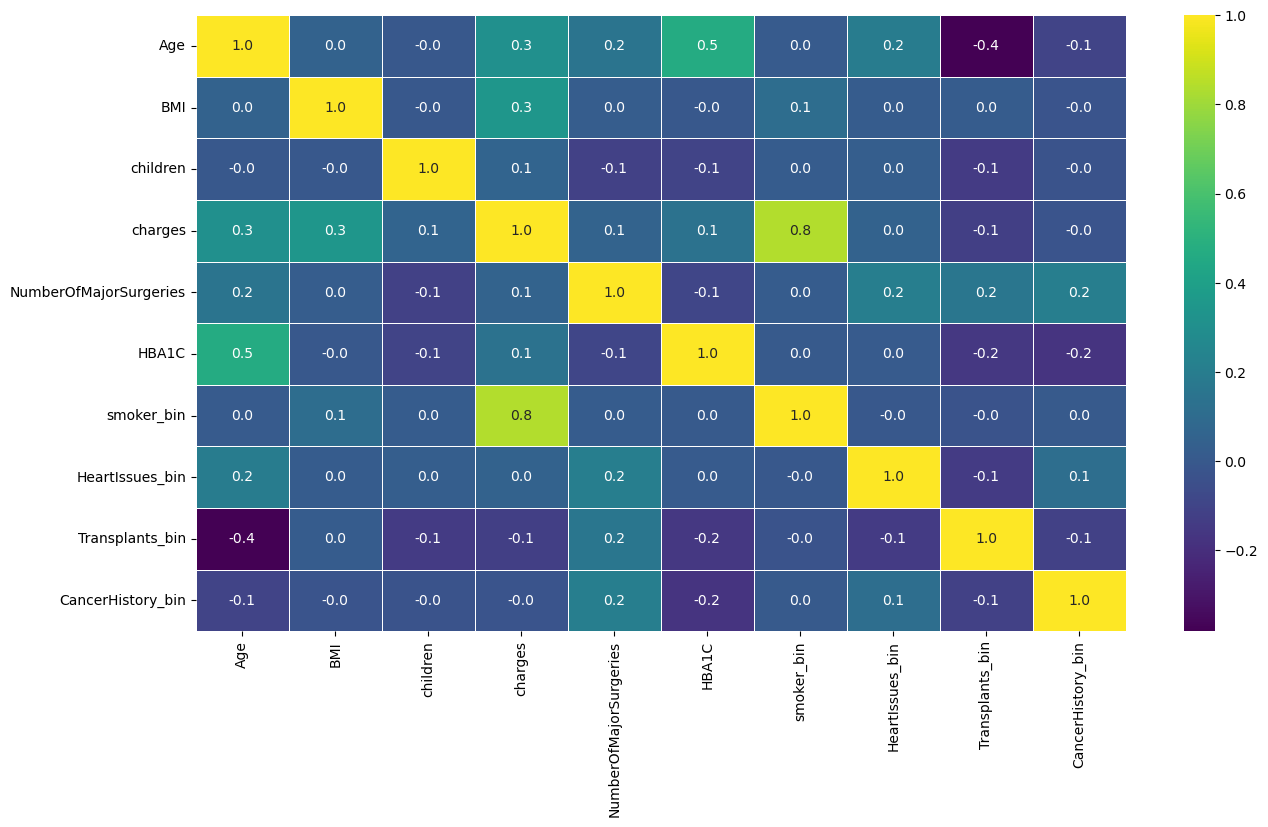

In [34]:
# plot correlation map

corr_cols = ['Age','BMI','children','charges','NumberOfMajorSurgeries','HBA1C','smoker_bin',
             'HeartIssues_bin','Transplants_bin','CancerHistory_bin']

corr = data[corr_cols]
corr_mat =  corr.corr()
plt.figure(figsize = (15,8))
sns.heatmap(corr_mat, annot = True, fmt = '.1f', linewidths = 0.5, cmap = 'viridis')
plt.show()

The data is mostly made up of independent features with most showing no correlation, with only two relationships showing 50% or more correlation, which are HBA1C and age with a correlation of 50%, and a very significant correlation between smokers and charge of 80%. This shows that smoking has a very big influence in hospitalization costs.

In [35]:
data.columns

Index(['Customer ID', 'children', 'charges', 'Hospital tier', 'City tier',
       'name', 'BMI', 'HBA1C', 'Heart Issues', 'Any Transplants',
       'Cancer history', 'NumberOfMajorSurgeries', 'smoker', 'State_R1011',
       'State_R1012', 'State_R1013', 'DOB', 'Age', 'Gender',
       'Hospital_tier_ord', 'City_tier_ord', 'smoker_bin', 'HeartIssues_bin',
       'Transplants_bin', 'CancerHistory_bin', 'Gender_bin'],
      dtype='object')

In [36]:
#drop unnecessary columns
data = data.drop(columns =['Customer ID','name', 'DOB', 'Hospital tier','City tier','smoker','Heart Issues',
                 'Any Transplants','Cancer history','Gender'])

In [37]:
# Target Column and feature separation
X = data.drop(columns =['charges'])
y = data['charges']

### Linear Regression

In [55]:
#Set up regression pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipeline_lr

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [52]:
#Setup Strattified 5-fold
kf = KFold(n_splits=5, shuffle = True, random_state= 42)
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [56]:
#Evaluate Model
score_lr = cross_val_score(pipeline_lr, X, y, scoring='r2', cv=kf)
print("Linear Regression CV R2:", score_lr)
print(f"Linear Mean R2: {score_lr.mean():.4f} | Std: {score_lr.std():.4f}")

Linear Regression CV R2: [0.83754022 0.83464231 0.87792902 0.86641281 0.86988376]
Linear Mean R2: 0.8573 | Std: 0.0177


### Ridge Regression

In [57]:
#Setup ridge pipeline
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
    ])
pipeline_ridge

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

In [60]:
#Set parameters
param_grid = {
    'model__alpha': np.logspace(-3, 3, 20)
}

#Search for best params

ridge_search = GridSearchCV(
    pipeline_ridge,
    param_grid=param_grid,
    scoring='r2',
    cv=kf
)
ridge_search.fit(X, y)
print("Best Ridge Params:", ridge_search.best_params_)
print(f"Best Ridge CV R2: {ridge_search.best_score_:.4f}")

Best Ridge Params: {'model__alpha': 6.158482110660261}
Best Ridge CV R2: 0.8573


### Gradient Boosting

In [61]:
##etup gradient bossting pipeline
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=42))
])
pipeline_gb

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', GradientBoostingRegressor(random_state=42))])

In [63]:
score_gb = cross_val_score(pipeline_gb, X, y, scoring='r2', cv=kf)
print("Gradient Boost CV R2:", score_gb)
print(f"GBR Mean R2: {score_gb.mean():.4f} | Std: {score_gb.std():.4f}")

Gradient Boost CV R2: [0.88987254 0.88437411 0.93602439 0.92507088 0.91357617]
GBR Mean R2: 0.9098 | Std: 0.0199


In [65]:
#Create folds
df_ml = X.copy()
df_ml['charges'] = y
df_ml['fold'] = -1

for fold_id, (_, val_idx) in enumerate(kf.split(X)):
    df_ml.loc[df_ml.index[val_idx], 'fold'] = fold_id

df_ml['fold'].value_counts().sort_index()

0    465
1    465
2    465
3    465
4    465
Name: fold, dtype: int64

### Feature Importance (Gradient Boosting))

In [67]:
#feature importance
pipeline_gb.fit(X, y)

fi = pd.Series(
    pipeline_gb.named_steps['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fi.head(20)

smoker_bin                0.751288
BMI                       0.112873
Age                       0.092180
Hospital_tier_ord         0.021570
State_R1011               0.007214
children                  0.006277
State_R1013               0.004617
HBA1C                     0.003237
Gender_bin                0.000480
State_R1012               0.000114
CancerHistory_bin         0.000078
NumberOfMajorSurgeries    0.000037
City_tier_ord             0.000025
Transplants_bin           0.000011
HeartIssues_bin           0.000000
dtype: float64

### Model Comparison

In [68]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (best)', 'Gradient Boost'],
    'Mean_CV_R2': [score_lr.mean(), ridge_search.best_score_, score_gb.mean()],
    'Std_CV_R2':  [score_lr.std(), np.nan, score_gb.std()]
}).sort_values('Mean_CV_R2', ascending=False)

results

,Model,Mean_CV_R2,Std_CV_R2
2,Gradient Boost,0.909784,0.019893
1,Ridge (best),0.857300,NaN
0,Linear Regression,0.857282,0.017724


Of the three models evaluated using 5kfold cross validation Gradient Boosting achieved the highest performance with a mean r2 of 0.91, with ridge and linear regression showing slightly worse performances.

### Use Case

In [74]:
#use case patient card
height = 170
weight = 85
bmi = weight / (height/100)**2
dob = pd.Timestamp('1988-12-28')
age_use = int((today-dob).days//365)

37

In [81]:
# create DataFrame
# create dict with X columns
jayna = pd.DataFrame([{c:0 for c in X.columns}])
jayna

,children,BMI,HBA1C,NumberOfMajorSurgeries,State_R1011,State_R1012,State_R1013,Age,Hospital_tier_ord,City_tier_ord,smoker_bin,HeartIssues_bin,Transplants_bin,CancerHistory_bin,Gender_bin
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [82]:
# Fill known values 
jayna.loc[0, 'Age'] = age_use
jayna.loc[0, 'BMI'] = bmi
jayna.loc[0, 'HBA1C'] = 5.8
jayna.loc[0, 'children'] = 2
jayna.loc[0, 'smoker_bin'] = 1
jayna.loc[0, 'Gender_bin'] = 0   # femele ->0
jayna.loc[0, 'Hospital_tier_ord'] = 2  # tier-1 -> 3 
jayna.loc[0, 'City_tier_ord'] = 2  # tier-1 -> 3
jayna.loc[0, 'State_R1011'] = 1
jayna.loc[0, 'Transplants_bin'] = 0
jayna.loc[0, 'HeartIssues_bin'] = 0
jayna.loc[0, 'NumberOfMajorSurgeries'] = 0
jayna.loc[0, 'CancerHistory_bin'] = 1
jayna

,children,BMI,HBA1C,NumberOfMajorSurgeries,State_R1011,State_R1012,State_R1013,Age,Hospital_tier_ord,City_tier_ord,smoker_bin,HeartIssues_bin,Transplants_bin,CancerHistory_bin,Gender_bin
0,2,29.411765,5.8,0,1,0,0,37,2,2,1,0,0,1,0


In [89]:
# Predict cost for Jayna
pipeline_lr.fit(X, y)
best_ridge = ridge_search.best_estimator_

pred_lr = float(pipeline_lr.predict(jayna)[0])
pred_ridge = float(best_ridge.predict(jayna)[0])
pred_gb = float(pipeline_gb.predict(jayna)[0])

preds = pd.DataFrame({
    'Model': ['Linear Regression', f'Ridge (alpha={ridge_search.best_params_["model__alpha"]:.4f})', 'Gradient Boost'],
    'Predicted Cost': [pred_lr, pred_ridge, pred_gb]
})

preds

,Model,Predicted Cost
0,Linear Regression,31876.817348
1,Ridge (alpha=6.1585),31842.847276
2,Gradient Boost,28473.074972


Using the best model's (Gradient Boosting) prediction, the estimated hospitalization cost for Jaynah is aproximately 28,473$.